# Run SMITH-Agent panel evaluation

This notebook starts from real H5AD inputs and writes a fresh ranking, panel, evaluation and run manifest. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/agent_section/05_SMITH_Agent_Evaluation_source.ipynb).

## Set data and output locations

In [1]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'agent'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", '1'))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')
print("Input and output roots are configured. Set SMITH_TUTORIAL_DATA/OUTPUT to override them.")

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


Input and output roots are configured. Set SMITH_TUTORIAL_DATA/OUTPUT to override them.


## Check real input files

In [2]:
inputs = ['agent/liver_merfish/adata_healthy_nucseq.h5ad', 'agent/liver_merfish/adata_healthy_merfish.h5ad', 'agent/references/PSC011_C1_visium.h5ad', 'agent/references/WSSS_F_IMMsp9838712_visium.h5ad']
input_rows = []
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    digest = sha256_file(path)
    input_rows.append({"file": relative, "bytes": path.stat().st_size, "sha256": digest})
display(pd.DataFrame(input_rows))


,file,bytes,sha256
0,agent/liver_merfish/adata_healthy_nucseq.h5ad,1262101004,faa8897adfc86a436053c28e7d5012a422335a00f9faf3...
1,agent/liver_merfish/adata_healthy_merfish.h5ad,350386069,6b7fc5879a78b03002d94500ceffb3dcebef4cea82c29b...
2,agent/references/PSC011_C1_visium.h5ad,157609327,21f3710fd52fb842d24c2dee30c8be42a22f451935cdf2...
3,agent/references/WSSS_F_IMMsp9838712_visium.h5ad,314137660,c2f418c03d5792852d27210770ad4b094e9abb7c2fca9b...


## Run the workflow

In [3]:
command = [
    sys.executable, str(ROOT / 'reproducibility/workflows/agent/run_tutorial.py'),
    "--data-root", str(DATA_ROOT),
    "--output-dir", str(CASE_OUTPUT),
    "--device", DEVICE,
    "--epochs", str(EPOCHS),
    "--seed", "42",
] + ['--panel-size', '64', '--max-cells', '3000']
display_command = [
    "python", 'reproducibility/workflows/agent/run_tutorial.py', "--data-root", "data/tutorials",
    "--output-dir", "outputs/tutorials/agent", "--device", DEVICE,
    "--epochs", str(EPOCHS), "--seed", "42",
] + ['--panel-size', '64', '--max-cells', '3000']
print(" ".join(display_command))
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
print("Completed:", manifest["workflow"], "->", "outputs/tutorials/agent/run_manifest.json")


python reproducibility/workflows/agent/run_tutorial.py --data-root data/tutorials --output-dir outputs/tutorials/agent --device cpu --epochs 1 --seed 42 --panel-size 64 --max-cells 3000


Completed: 05_agent -> outputs/tutorials/agent/run_manifest.json


## Inspect newly generated outputs

In [4]:
panel_path = CASE_OUTPUT / 'aggregation/integrated_top_64_panel.tsv'
ranking_path = sorted(CASE_OUTPUT.glob('aggregation/integrated_panel_rank.tsv'))[-1]
metrics_path = CASE_OUTPUT / 'evaluation/metrics.tsv'
panel = pd.read_csv(panel_path, sep="\t" if panel_path.suffix == ".tsv" else ",")
ranking = pd.read_csv(ranking_path, sep="\t" if ranking_path.suffix == ".tsv" else ",")
metrics = pd.read_csv(metrics_path, sep="\t")
print("Generated panel:", panel_path.relative_to(CASE_OUTPUT))
display(panel.head(15))
print("Generated ranking:", ranking_path.relative_to(CASE_OUTPUT))
display(ranking.head(10))
display(metrics)


Generated panel: aggregation/integrated_top_64_panel.tsv


,integrated_rank,gene_symbol,source_score,reference_1_score,reference_2_score,reference_support,mean_reference_score,integrated_score
0,1,TM4SF4,0.961290,0.883495,0.993528,2,0.938511,0.951040
1,2,PLPP3,0.996774,0.773463,0.977346,2,0.875405,0.942158
2,3,CLMN,0.980645,0.919094,0.750809,2,0.834951,0.915083
3,4,PRKCE,0.990323,0.915858,0.711974,2,0.813916,0.910940
4,5,SCD,0.822581,0.996764,1.000000,2,0.998382,0.901691
5,6,PPARG,0.900000,0.974110,0.799353,2,0.886731,0.894029
6,7,ALAS1,0.877419,0.967638,0.789644,2,0.878641,0.877969
7,8,CP,0.841935,0.951456,0.825243,2,0.888350,0.862822
8,9,DTNA,0.983871,0.825243,0.601942,2,0.713592,0.862246
9,10,LAMA4,0.916129,0.880259,0.702265,2,0.791262,0.859939


Generated ranking: aggregation/integrated_panel_rank.tsv


,integrated_rank,gene_symbol,source_score,reference_1_score,reference_2_score,reference_support,mean_reference_score,integrated_score
0,1,TM4SF4,0.961290,0.883495,0.993528,2,0.938511,0.951040
1,2,PLPP3,0.996774,0.773463,0.977346,2,0.875405,0.942158
2,3,CLMN,0.980645,0.919094,0.750809,2,0.834951,0.915083
3,4,PRKCE,0.990323,0.915858,0.711974,2,0.813916,0.910940
4,5,SCD,0.822581,0.996764,1.000000,2,0.998382,0.901691
5,6,PPARG,0.900000,0.974110,0.799353,2,0.886731,0.894029
6,7,ALAS1,0.877419,0.967638,0.789644,2,0.878641,0.877969
7,8,CP,0.841935,0.951456,0.825243,2,0.888350,0.862822
8,9,DTNA,0.983871,0.825243,0.601942,2,0.713592,0.862246
9,10,LAMA4,0.916129,0.880259,0.702265,2,0.791262,0.859939


,panel,metric,value
0,source,cell_type_accuracy,6.148103e-01
1,source,cell_type_balanced_accuracy,6.820688e-01
2,source,cell_type_macro_f1,6.133048e-01
3,source,cell_type_weighted_f1,6.240688e-01
4,source,spatial_mse,1.977148e+06
5,source,spatial_mae,1.099428e+03
6,source,spatial_distance_mae,1.747541e+03
7,source,spatial_distance_median,1.596145e+03
8,source,spatial_pearson,7.795534e-01
9,multi_reference,cell_type_accuracy,6.278620e-01


## Analyze this run

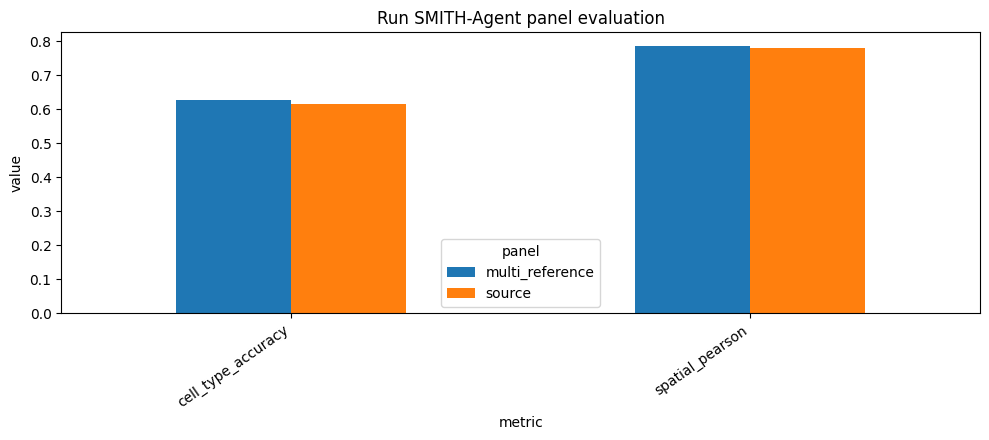

In [5]:
metrics = metrics[metrics["metric"].isin(['cell_type_accuracy', 'spatial_pearson'])].copy()
plot_data = metrics.pivot_table(index='metric', columns='panel', values="value", aggfunc="mean")
ax = plot_data.plot(kind="bar", figsize=(10, 4.5))
ax.set_ylabel("value")
ax.set_title('Run SMITH-Agent panel evaluation')
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Tutorial run versus manuscript run

The tutorial trains a source panel and two real spatial-reference panels before rank aggregation. The paper-scale run uses five references and more seeds. Probe filtering is a separate backend-dependent stage and no pass rate is fabricated here.